#### Extracting Pipeline Components

In [14]:
import joblib

pipeline = joblib.load("../artifacts/xgboost_fraud_detector.joblib")

In [15]:
preprocessor = pipeline.named_steps["preprocessor"]
xgb_model = pipeline.named_steps["model"]

In [16]:
print(preprocessor)
print(xgb_model)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['type']),
                                ('num', 'passthrough',
                                 ['step', 'amount', 'oldbalance_org',
                                  'newbalance_orig', 'oldbalance_dest',
                                  'newbalance_dest', 'diff_new_old_balance',
                                  'diff_new_old_dest'])])
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_de

#### Preparing Sample Data

In [17]:
import pandas as pd

df = pd.read_csv("../data/raw/fraud_0.1origbase.csv")

In [18]:
df.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
72510,35,CASH_IN,337748.44,C352197488,51883.0,389631.44,C627487261,0.0,0.0,0,0


In [19]:
df["diff_new_old_balance"] = (
    df["newbalanceOrig"] - df["oldbalanceOrg"]
)

df["diff_new_old_dest"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

#### Renaming Columns

In [20]:
import inflection
df.columns = [inflection.underscore(col) for col in df.columns]

#### Creating Input Matrix

In [21]:
features = [
    'type',
    'step',
    'amount',
    'oldbalance_org',
    'newbalance_orig',
    'oldbalance_dest',
    'newbalance_dest',
    'diff_new_old_balance',
    'diff_new_old_dest'
]

X = df[features].sample(1000, random_state=42)

#### Transforming Data

In [22]:
X_transformed = preprocessor.transform(X)

In [23]:
X_transformed.shape

(1000, 13)

In [24]:
feature_names = preprocessor.get_feature_names_out()

In [25]:
feature_names

array(['cat__type_CASH_IN', 'cat__type_CASH_OUT', 'cat__type_DEBIT',
       'cat__type_PAYMENT', 'cat__type_TRANSFER', 'num__step',
       'num__amount', 'num__oldbalance_org', 'num__newbalance_orig',
       'num__oldbalance_dest', 'num__newbalance_dest',
       'num__diff_new_old_balance', 'num__diff_new_old_dest'],
      dtype=object)

#### SHAP Explainer

In [ ]:
import shap
explainer = shap.TreeExplainer(xgb_model)

In [27]:
shap_values = explainer.shap_values(X_transformed)

In [28]:
shap_values.shape

(1000, 13)

#### Plots

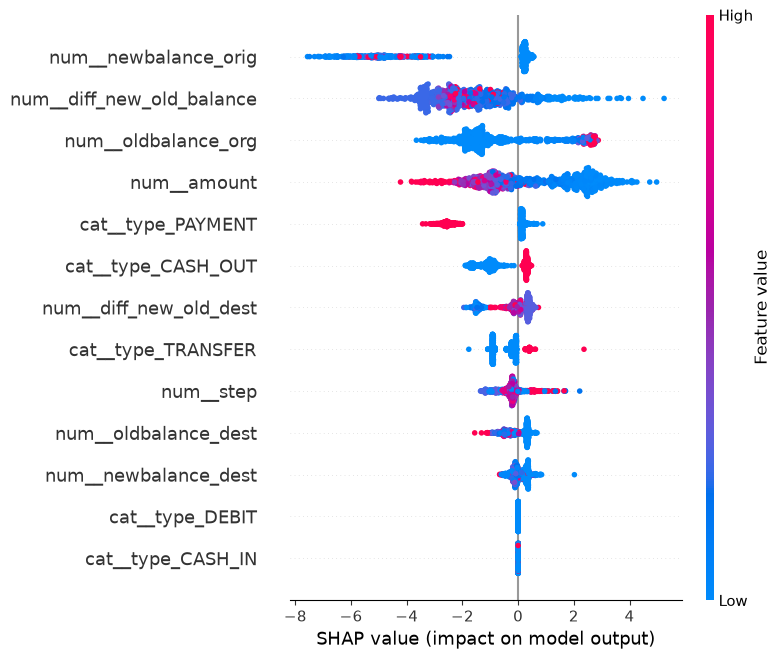

<Figure size 640x480 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

plt.tight_layout()
plt.savefig("../reports/shap_summary.png")
plt.show()

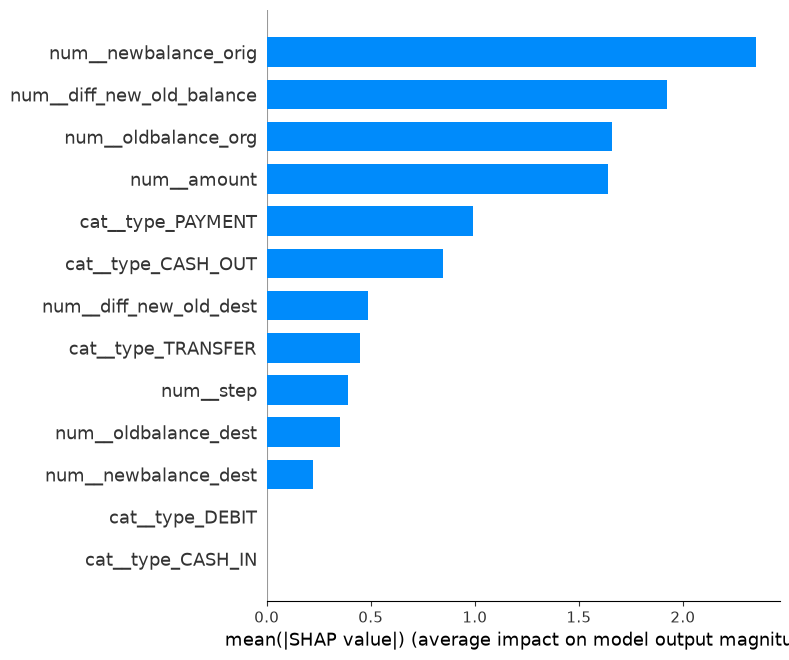

In [31]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("../reports/shap_bar.png")
plt.show()